# Build crop configs for new sessions

For each new session in `/mnt/m/Data/VideoAnalysisTools/`, hand-tune a pixel-based crop config consumed by `video_preprocessing_utils.get_video_transforms` (the ground-truth transformation pipeline, same one used in `test_tim_videos.ipynb` and `convert_videos_to_hdf5`), visualize the crop box on the original frame and the resulting transformed frame, and save the config to `configs/crop_configs/{session_name}.json`.

Workflow per session:
1. Set `session_name` below and locate its single trial video.
2. Adjust the crop values in `crop_config` and re-run the preview cell until the crop box looks right.
3. Run the save cell to persist the config, then run the validation cell to confirm the saved config reproduces the same transform and to save the final figure.

In [14]:
import json
import os
import glob
import sys

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from torchcodec.decoders import VideoDecoder

sys.path.append('/home/kurgyis/Research/VideoAnalysisTools/src/')

import preprocessing.video_preprocessing_utils as video_utils

## Locate the session video

In [28]:
data_root = '/mnt/m/Data/VideoAnalysisTools/'
crop_config_dir = '../configs/crop_configs'
figure_dir = '../figures/crop_config_visualization'

available_sessions = sorted(os.listdir(data_root))
existing_configs = sorted(f.replace('.json', '') for f in os.listdir(crop_config_dir) if f.endswith('.json'))
print(f"{len(available_sessions)} sessions found, {len(existing_configs)} already have a config:")
print("Done:", existing_configs)
print("Remaining:", [s for s in available_sessions if s not in existing_configs])

21 sessions found, 2 already have a config:
Done: ['alm_side', 'kd115_twNew_20221206_115814']
Remaining: ['kd102_twNew_20220929_133826', 'kd102_twNew_20221019_192919', 'kd102_twNew_20221104_191623', 'kd102_twNew_20221117_115025', 'kd104_twNew_20221117_183439', 'kd104_twNew_20221122_193526', 'kd104_twNew_20221124_104921', 'kd104_twNew_20221128_181805', 'kd111_twNew_20221020_182700', 'kd111_twNew_20221022_210621', 'kd111_twNew_20221030_212434', 'kd111_twNew_20221117_150650', 'kd115_twNew_20221119_214250', 'kd115_twNew_20221128_115825', 'kd115_twNew_20221130_105141', 'kd115_twNew_20221209_110723', 'kd95_twNew_20220830_232041', 'kd95_twNew_20220922_141851', 'kd95_twNew_20220923_145003', 'kd95_twNew_20221004_104619']


In [163]:
# <-- change this per session
session_name = available_sessions[20]

if session_name not in available_sessions:
    raise ValueError(f"Session {session_name} not found in {data_root}. Available sessions: {available_sessions}")
elif session_name in existing_configs:
    #warning
    print(f"Session {session_name} already has a config in {crop_config_dir}. Existing configs: {existing_configs}\n---\n")

session_dir = os.path.join(data_root, session_name)
video_paths = glob.glob(os.path.join(session_dir, '*.mp4'))
assert len(video_paths) == 1, f"Expected exactly one .mp4 in {session_dir}, found {len(video_paths)}"
video_path = video_paths[0]

decoder = VideoDecoder(video_path)
num_frames = len(decoder)
sample_frame_indices = [0, num_frames // 2, num_frames - 1]
print(video_path)
print(f"num_frames = {num_frames}, sample_frame_indices = {sample_frame_indices}")

/mnt/m/Data/VideoAnalysisTools/kd95_twNew_20221004_104619/kd95_side_trial245_date_2022_10_04_time_11_55_19.mp4
num_frames = 2024, sample_frame_indices = [0, 1012, 2023]


## Hand-tune the crop config

Same schema as `config['data']` in `configs/ae_config.json` (pixel-based `crop_top`/`crop_bottom`/`crop_left`/`crop_right` plus `image_height`/`image_width`), which is exactly what `video_utils.get_video_transforms` consumes.

In [164]:
crop_config = {
    "image_height": 120,
    "image_width": 112,
    "crop_top": 45,
    "crop_bottom": 70,
    "crop_left": 240,
    "crop_right": 0,
}
crop_config

{'image_height': 120,
 'image_width': 112,
 'crop_top': 45,
 'crop_bottom': 70,
 'crop_left': 240,
 'crop_right': 0}

In [165]:
def plot_crop_pipeline(video_path, decoder, sample_indices, crop_config, transforms, title, save_path=None):
    """transforms must be video_utils.get_video_transforms({'data': crop_config}) - the ground-truth pipeline."""
    fig, axes = plt.subplots(nrows=len(sample_indices), ncols=2, figsize=(7, 3 * len(sample_indices)))
    fig.suptitle(f"{title}\n{os.path.basename(video_path)}", fontsize=14)

    c_top = crop_config['crop_top']
    c_bot = crop_config['crop_bottom']
    c_left = crop_config['crop_left']
    c_right = crop_config['crop_right']

    for row_idx, frame_idx in enumerate(sample_indices):
        orig_tensor = decoder.get_frame_at(frame_idx).data
        trans_tensor = transforms(orig_tensor)

        orig_img = orig_tensor.permute(1, 2, 0).numpy()
        trans_img = trans_tensor.permute(1, 2, 0).numpy()

        ax_orig = axes[row_idx, 0]
        ax_orig.imshow(orig_img)
        ax_orig.set_title(f"Original Frame {frame_idx}\nShape: {tuple(orig_tensor.shape)}")
        ax_orig.axis('off')

        H, W, _ = orig_img.shape
        box_width = W - c_left - c_right
        box_height = H - c_top - c_bot
        rect = patches.Rectangle(
            (c_left, c_top), box_width, box_height,
            linewidth=2.5, edgecolor='green', facecolor='none'
        )
        ax_orig.add_patch(rect)

        ax_trans = axes[row_idx, 1]
        ax_trans.imshow(trans_img, cmap='gray')
        ax_trans.set_title(f"Transformed Frame {frame_idx}\nShape: {tuple(trans_tensor.shape)}")
        ax_trans.axis('off')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

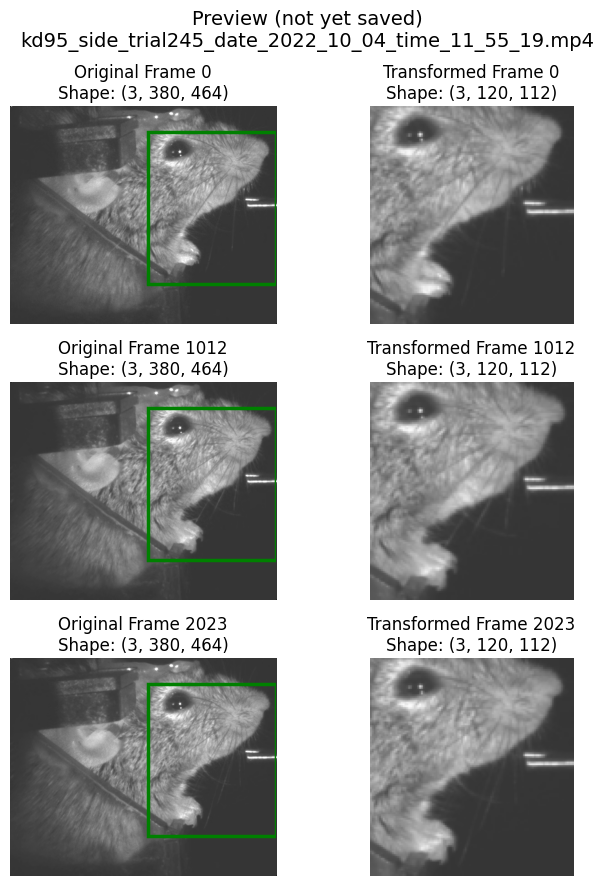

In [166]:
# Re-run this cell after editing crop_config above until the crop box + transformed frame look right.
transforms = video_utils.get_video_transforms({'data': crop_config})
plot_crop_pipeline(
    video_path, decoder, sample_frame_indices, crop_config, transforms,
    title="Preview (not yet saved)"
)

## Save the config and validate

Only run this once you're happy with the preview above.

In [167]:
os.makedirs(crop_config_dir, exist_ok=True)
os.makedirs(figure_dir, exist_ok=True)

config_out_path = os.path.join(crop_config_dir, f'{session_name}.json')
with open(config_out_path, 'w') as f:
    json.dump(crop_config, f, indent=2)
print(f"Saved crop config to {config_out_path}")

Saved crop config to ../configs/crop_configs/kd95_twNew_20221004_104619.json


Saved config reproduces the previewed transform.


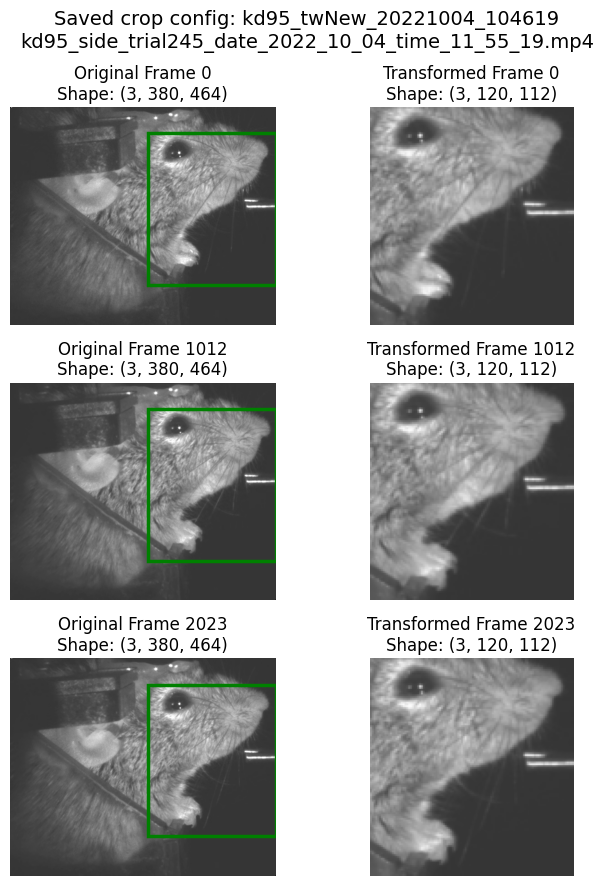

Saved figure to ../figures/crop_config_visualization/kd95_twNew_20221004_104619.png


In [168]:
with open(config_out_path, 'r') as f:
    saved_config = json.load(f)
saved_transforms = video_utils.get_video_transforms({'data': saved_config})

for frame_idx in sample_frame_indices:
    orig_tensor = decoder.get_frame_at(frame_idx).data
    assert torch.allclose(transforms(orig_tensor), saved_transforms(orig_tensor)), \
        f"Saved config transform mismatch at frame {frame_idx}"
print("Saved config reproduces the previewed transform.")

figure_save_path = os.path.join(figure_dir, f'{session_name}.png')
plot_crop_pipeline(
    video_path, decoder, sample_frame_indices, saved_config, saved_transforms,
    title=f"Saved crop config: {session_name}",
    save_path=figure_save_path
)
print(f"Saved figure to {figure_save_path}")